In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, gc, os, glob
warnings.filterwarnings('ignore')

import lightgbm as lgb
# import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

print('LightGBM:', lgb.__version__)

LightGBM: 4.6.0


In [2]:
# Cell 2 — Memory helper
def reduce_mem(df, verbose=True):
    start = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        dtype = df[col].dtype
        if str(dtype) in ['int64','int32','int16','int8']:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif str(dtype) in ['float64','float32']:
            df[col] = pd.to_numeric(df[col], downcast='float')
    end = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'  Memory: {start:.1f}MB -> {end:.1f}MB ({100*(start-end)/start:.0f}% reduction)')
    return df

In [3]:
# Cell 4 — Application feature engineering
def application_features(df):
    df = df.copy()
    # Basic ratios
    df['CREDIT_INCOME_RATIO']      = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO']     = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_ANNUITY_RATIO']     = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
    df['CREDIT_GOODS_RATIO']       = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)
    df['GOODS_INCOME_RATIO']       = df['AMT_GOODS_PRICE'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['INCOME_PER_PERSON']        = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
    df['INCOME_PER_CHILD']         = df['AMT_INCOME_TOTAL'] / (df['CNT_CHILDREN'] + 1)
    # Age/employment
    df['EMPLOYED_TO_BIRTH_RATIO']  = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    df['DAYS_EMPLOYED_PERC']       = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    df['CAR_TO_BIRTH_RATIO']       = df['OWN_CAR_AGE'] / ((-df['DAYS_BIRTH'] / 365) + 1)
    df['PHONE_TO_BIRTH_RATIO']     = df['DAYS_LAST_PHONE_CHANGE'] / (df['DAYS_BIRTH'] + 1)
    df['PHONE_TO_EMPLOY_RATIO']    = df['DAYS_LAST_PHONE_CHANGE'] / (df['DAYS_EMPLOYED'] + 1)
    # External sources (strongest predictors)
    df['EXT_SOURCE_MEAN']          = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCE_STD']           = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
    df['EXT_SOURCE_PROD']          = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['EXT_SOURCE_MIN']           = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)
    df['EXT_SOURCE_MAX']           = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].max(axis=1)
    df['EXT12']                    = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2']
    df['EXT13']                    = df['EXT_SOURCE_1'] * df['EXT_SOURCE_3']
    df['EXT23']                    = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    # Document flags: count how many docs submitted
    doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
    df['DOCS_COUNT']               = df[doc_cols].sum(axis=1)
    # Flag: anomalous employment (365243 = not employed)
    df['EMPLOYED_IS_ANOMALY']      = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED']            = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    # Credit term
    df['CREDIT_TERM']              = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
    # Social circle anomaly
    df['OBS_DEF_RATIO_30']         = df['DEF_30_CNT_SOCIAL_CIRCLE'] / (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
    df['OBS_DEF_RATIO_60']         = df['DEF_60_CNT_SOCIAL_CIRCLE'] / (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)
    return df

# app_train = application_features(app_train)
# app_test  = application_features(app_test)
# print(f'Application shape: {app_train.shape}')

In [4]:
# Cell 5 — bureau.csv
bureau = pd.read_csv('../Data/batches/bureau.csv')
print(f'bureau: {bureau.shape}')

bureau['IS_ACTIVE']         = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau['IS_CLOSED']         = (bureau['CREDIT_ACTIVE'] == 'Closed').astype(int)
bureau['IS_BAD']            = (bureau['CREDIT_ACTIVE'] == 'Bad debt').astype(int)
bureau['OVERDUE_RATIO']     = bureau['AMT_CREDIT_SUM_OVERDUE'] / (bureau['AMT_CREDIT_SUM'] + 1)
bureau['DEBT_RATIO']        = bureau['AMT_CREDIT_SUM_DEBT'] / (bureau['AMT_CREDIT_SUM'] + 1)
bureau['CREDIT_ENDDATE_DIFF'] = bureau['DAYS_CREDIT_ENDDATE'] - bureau['DAYS_CREDIT']

agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU':             'count',
    'CREDIT_TYPE':              'nunique',
    'IS_ACTIVE':                ['sum','mean'],
    'IS_CLOSED':                ['sum','mean'],
    'IS_BAD':                   ['sum','mean'],
    'AMT_CREDIT_SUM_DEBT':      ['sum','mean','max'],
    'AMT_CREDIT_SUM':           ['sum','mean','max'],
    'AMT_CREDIT_SUM_OVERDUE':   ['sum','max'],
    'AMT_CREDIT_SUM_LIMIT':     ['mean','max'],
    'DAYS_CREDIT':              ['mean','min','max','std'],
    'DAYS_CREDIT_ENDDATE':      ['mean','max'],
    'DAYS_CREDIT_UPDATE':       'mean',
    'AMT_ANNUITY':              ['mean','sum','max'],
    'CNT_CREDIT_PROLONG':       'sum',
    'OVERDUE_RATIO':            'mean',
    'DEBT_RATIO':               'mean',
    'CREDIT_ENDDATE_DIFF':      'mean',
})
agg.columns = ['BUREAU_' + '_'.join(c).upper() for c in agg.columns]
agg = agg.reset_index()

agg['BUREAU_DEBT_CREDIT_RATIO']  = agg['BUREAU_AMT_CREDIT_SUM_DEBT_SUM'] / (agg['BUREAU_AMT_CREDIT_SUM_SUM'] + 1)
agg['BUREAU_ACTIVE_RATIO']       = agg['BUREAU_IS_ACTIVE_SUM'] / (agg['BUREAU_SK_ID_BUREAU_COUNT'] + 1)
agg['BUREAU_OVERDUE_CREDIT_RATIO'] = agg['BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM'] / (agg['BUREAU_AMT_CREDIT_SUM_SUM'] + 1)

# app_train = app_train.merge(agg, on='SK_ID_CURR', how='left')
# app_test  = app_test.merge(agg,  on='SK_ID_CURR', how='left')
# print(f'After bureau merge: {app_train.shape}')
# del bureau, agg; gc.collect()

bureau: (1716428, 17)


In [5]:
# Cell 6 — bureau_balance.csv
bb = pd.read_csv('../Data/batches/bureau_balance.csv')
print(f'bureau_balance: {bb.shape}')

bb_dummies = pd.get_dummies(bb['STATUS'], prefix='BB_STATUS')
bb = pd.concat([bb[['SK_ID_BUREAU','MONTHS_BALANCE']], bb_dummies], axis=1)
status_cols = [c for c in bb.columns if c.startswith('BB_STATUS_')]

agg_dict = {'MONTHS_BALANCE': ['count','min','max']}
for c in status_cols:
    agg_dict[c] = 'mean'
bb_bureau = bb.groupby('SK_ID_BUREAU').agg(agg_dict)
bb_bureau.columns = ['BB_MONTHS_COUNT','BB_MONTHS_MIN','BB_MONTHS_MAX'] + [c+'_MEAN' for c in status_cols]
bb_bureau = bb_bureau.reset_index()

bureau_key = pd.read_csv('../Data/batches/bureau.csv', usecols=['SK_ID_BUREAU','SK_ID_CURR'])
bb_bureau = bb_bureau.merge(bureau_key, on='SK_ID_BUREAU', how='left')

mean_cols = [c+'_MEAN' for c in status_cols]
client_dict = {'BB_MONTHS_COUNT':['mean','sum'], 'BB_MONTHS_MIN':'min', 'BB_MONTHS_MAX':'max'}
for c in mean_cols:
    client_dict[c] = ['mean','max']
bb_client = bb_bureau.drop('SK_ID_BUREAU',axis=1).groupby('SK_ID_CURR').agg(client_dict)
bb_client.columns = ['BB_CLIENT_'+'_'.join(c).upper() for c in bb_client.columns]
bb_client = bb_client.reset_index()

# app_train = app_train.merge(bb_client, on='SK_ID_CURR', how='left')
# app_test  = app_test.merge(bb_client,  on='SK_ID_CURR', how='left')
# print(f'After bureau_balance merge: {app_train.shape}')
# del bb, bb_dummies, bb_bureau, bureau_key, bb_client; gc.collect()

bureau_balance: (27299925, 3)


In [6]:
# Cell 3 — Load data
from sklearn.model_selection import train_test_split

# matches = glob.glob('../Data/batches/batch_0.csv', recursive=True)
# if not matches:
#     raise FileNotFoundError('Dataset not found. Add Home Credit data as input.')

# INPUT = os.path.dirname(matches[0])
# print(f'Dataset: {INPUT}')
# print('Files:', sorted(os.listdir(INPUT)))

app_train_full = pd.read_csv(f'../Data/batches/batch_0.csv')

app_train_full = application_features(app_train_full)
app_train_full = app_train_full.merge(agg, on='SK_ID_CURR', how='left')
app_train_full = app_train_full.merge(bb_client, on='SK_ID_CURR', how='left')

del bureau, agg; gc.collect()
del bb, bb_dummies, bb_bureau, bureau_key, bb_client; gc.collect()


print(f'Default rate: {app_train_full["TARGET"].mean():.3%}')

# 🔹 Train-Test Split (replaces app_test)
app_train, app_test = train_test_split(
    app_train_full,
    test_size=0.2,
    random_state=31,
    stratify=app_train_full['TARGET']
)

target_train = app_train['TARGET']
target_test  = app_test['TARGET']

print(f'Train: {app_train.shape}  |  Test: {app_test.shape}')

Default rate: 8.176%
Train: (20000, 203)  |  Test: (5000, 203)


In [7]:
# Cell 11 — Encode, Align, Reduce memory
# target   = app_train['TARGET']
# test_ids = app_test['SK_ID_CURR']

app_train = app_train.drop(['SK_ID_CURR','TARGET'], axis=1)
app_test  = app_test.drop(['SK_ID_CURR'], axis=1)

le = LabelEncoder()
for col in app_train.columns:
    if app_train[col].dtype == 'object':
        app_train[col] = app_train[col].fillna('Unknown')
        app_test[col]  = app_test[col].fillna('Unknown')
        le.fit(pd.concat([app_train[col], app_test[col]]))
        app_train[col] = le.transform(app_train[col])
        app_test[col]  = le.transform(app_test[col])

app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train = reduce_mem(app_train)
app_test  = reduce_mem(app_test, verbose=False)
print(f'Final — Train: {app_train.shape}  |  Test: {app_test.shape}')

  Memory: 29.4MB -> 13.8MB (53% reduction)
Final — Train: (20000, 201)  |  Test: (5000, 201)


In [8]:
# After preprocessing
X_train = app_train.values
y_train = target_train.values

X_test_np = app_test.values
y_test = target_test.values

In [11]:
import json

feature_list = list(app_train.columns)

with open("features.json", "w") as f:
    json.dump(feature_list, f)

In [75]:
# Cell 12 — LightGBM (tuned params, 10-fold)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'n_estimators':      10000,
    'learning_rate':     0.01,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'max_bin':           255,
    'subsample':         0.8,
    'subsample_freq':    1,
    'colsample_bytree':  0.6,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'min_split_gain':    0.02,
    'scale_pos_weight':  scale_pos_weight,
    'random_state':      42,
    'verbose':           -1,
    'n_jobs':            -1,
}

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X = app_train.values
y = target_train.values
X_test_np = app_test.values
feat_names = list(app_train.columns)

oof_lgb   = np.zeros(len(X))
test_lgb  = np.zeros(len(X_test_np))
scores_lgb = []
feature_imp = pd.DataFrame()

# Build callbacks
callbacks = []
if hasattr(lgb, 'early_stopping'):
    callbacks.append(lgb.early_stopping(200, verbose=False))
if hasattr(lgb, 'log_evaluation'):
    callbacks.append(lgb.log_evaluation(500))

print(f'Training LightGBM with {N_FOLDS}-fold CV...\n')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    Xtr, Xval = X[tr_idx], X[val_idx]
    ytr, yval = y[tr_idx], y[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    if callbacks:
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)], callbacks=callbacks)
    else:
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)],
                  early_stopping_rounds=200, verbose=500)

    oof_lgb[val_idx] = model.predict_proba(Xval)[:, 1]
    test_lgb += model.predict_proba(X_test_np)[:, 1] / N_FOLDS

    auc = roc_auc_score(yval, oof_lgb[val_idx])
    scores_lgb.append(auc)
    print(f'Fold {fold+1:2d} AUC: {auc:.5f}')

    imp = pd.DataFrame({'feature': feat_names,
                        'importance': model.feature_importances_, 'fold': fold+1})
    feature_imp = pd.concat([feature_imp, imp])

lgb_oof_auc = roc_auc_score(y, oof_lgb)
print(f'\nLightGBM OOF AUC: {lgb_oof_auc:.5f}')
print(f'Mean fold AUC:    {np.mean(scores_lgb):.5f} +/- {np.std(scores_lgb):.5f}')

Training LightGBM with 5-fold CV...

[500]	valid_0's auc: 0.749216
Fold  1 AUC: 0.75059
Fold  2 AUC: 0.75662
Fold  3 AUC: 0.74717
[500]	valid_0's auc: 0.748147
Fold  4 AUC: 0.74934
Fold  5 AUC: 0.75461

LightGBM OOF AUC: 0.74872
Mean fold AUC:    0.75167 +/- 0.00346


In [76]:
from sklearn.calibration import CalibratedClassifierCV

print("\nCalibrating probabilities...")

# X, y = full data → WRONG
# Instead use train split
calibrator = CalibratedClassifierCV(model, method='sigmoid', cv=2)
calibrator.fit(X_train, y_train)

# Use on test set
probs_test = calibrator.predict_proba(X_test_np)[:, 1]


Calibrating probabilities...


In [77]:
def expected_loss(y_true, probs, threshold=0.5,
                  loan_amt=10000,
                  profit_amt=2000):  # profit from good loan
    
    loss = 0
    
    for yt, p in zip(y_true, probs):
        
        if p <= threshold:  # APPROVED
            
            if yt == 1:
                loss += loan_amt      # default → loss
            else:
                loss -= profit_amt    # good → profit
    
    return loss / len(y_true)

loss = expected_loss(y_test, probs_test)
print(f"Expected Loss (default threshold=0.5): {loss:.2f}")

Expected Loss (default threshold=0.5): -1038.80


In [78]:
thresholds = np.linspace(0.1, 0.9, 50)

best_t = 0.5
best_loss = float('inf')

for t in thresholds:
    loss = expected_loss(y_test, probs_test, t)
    if loss < best_loss:
        best_loss = loss
        best_t = t

print(f"Best Threshold: {best_t:.3f}")
print(f"Minimum Expected Loss: {best_loss:.2f}")

Best Threshold: 0.100
Minimum Expected Loss: -1140.00


In [79]:
def make_decision(prob, threshold):
    return "REJECT" if prob > threshold else "APPROVE"


Computing SHAP values (sample)...


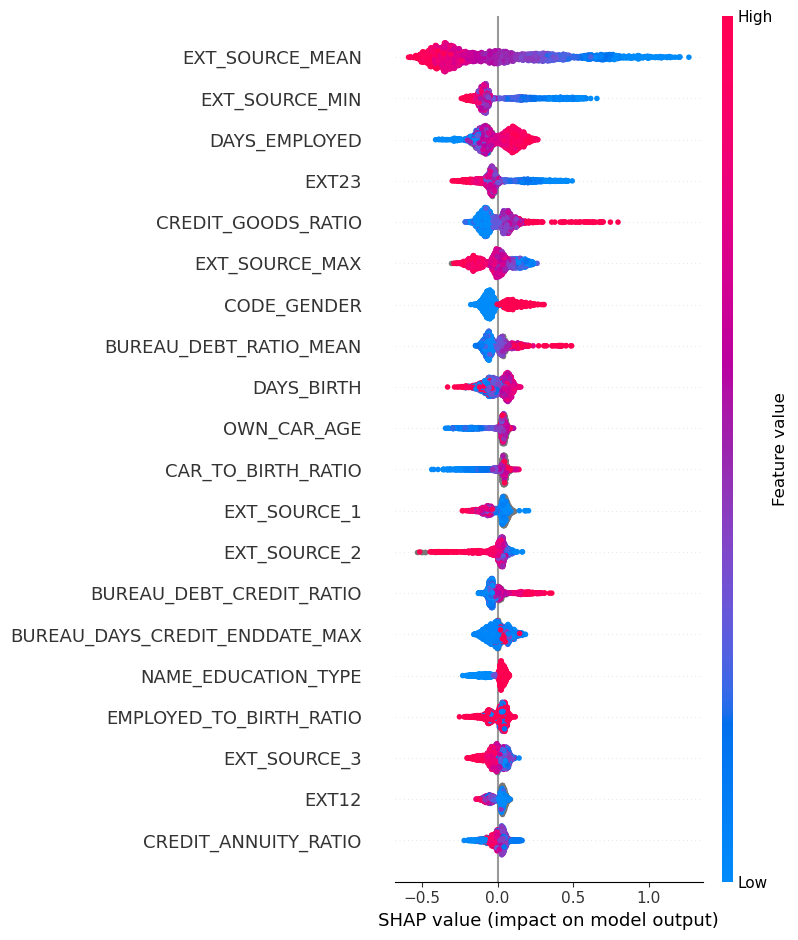

In [80]:
import shap

print("\nComputing SHAP values (sample)...")

# use TEST data
X_sample = app_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Global importance
shap.summary_plot(shap_values, X_sample)

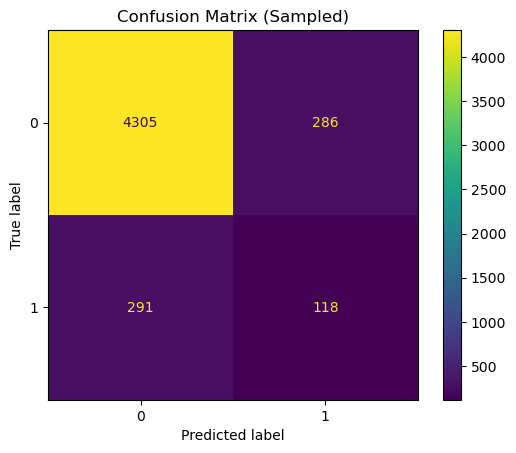

[[4305  286]
 [ 291  118]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4591
           1       0.29      0.29      0.29       409

    accuracy                           0.88      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.88      0.88      0.88      5000



In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

#  sample to avoid OOM
sample_idx = np.random.choice(len(y_test), size=5000, replace=False)

y_test_sample = y_test[sample_idx]
probs_sample = probs_test[sample_idx]

y_pred = (probs_sample > best_t).astype(int)

cm = confusion_matrix(y_test_sample, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d')
plt.title("Confusion Matrix (Sampled)")
plt.show()

print(cm)
print("\nClassification Report:\n")
print(classification_report(y_test_sample, y_pred))

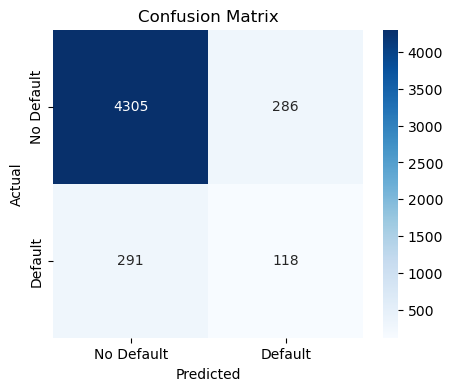

In [82]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()